# Model Visualisation Notebook

Evaluation and visualisation pipeline for trained classifiers.

This notebook is split into two independent sections:

1. **Section 1 — ConvNeXt-Tiny** (dataset classification, 3-class: Re-LAION 5B / StableDiffusion / COCO)
2. **Section 2 — ResNet-50** (attribute probe, binary or multi-class)

Each section covers:
- Model loading & dataset inference
- Normalised confusion matrix heatmap
- Per-class accuracy
- One-vs-Rest ROC / AUC curves
- Grad-CAM visualisations (correct & misclassified)
- Single-image and directory inference utilities

## Shared Imports & Utilities

Run this cell once before either section.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
sys.path.append(str(PROJECT_ROOT))

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

Using device: cuda


### Shared Visualisation & Inference Utilities

In [2]:
# ── Image de-normalisation helper ──────────────────────────────────────────

def _to_numpy_image(img_tensor):
    """Convert a normalised torch tensor (1,C,H,W) or (C,H,W) to a display-ready numpy array."""
    img = img_tensor.detach().cpu().numpy() if hasattr(img_tensor, "detach") else img_tensor
    if img.ndim == 4:
        img = img[0]
    if img.ndim == 3:
        C = img.shape[0]
        if C == 3:
            img = img * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
            img = np.clip(np.transpose(img, (1, 2, 0)), 0, 1)
            return img
        elif C == 1:
            return img[0]
    if img.ndim == 2:
        return img
    raise ValueError(f"Unsupported shape: {img.shape}")


# ── Grad-CAM ────────────────────────────────────────────────────────────────

class GradCAM:
    """Generic Grad-CAM wrapper — works with any target layer."""

    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(lambda m, i, o: self._save_activation(o))
        target_layer.register_full_backward_hook(lambda m, gi, go: self._save_gradient(go[0]))

    def _save_activation(self, output):
        self.activations = output.detach()

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        logits = self.model(input_tensor)
        logits[:, class_idx].sum().backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam


# ── Grad-CAM display ────────────────────────────────────────────────────────

def show_cam(entry, class_names=None, alpha=0.5):
    """Display original image alongside its Grad-CAM heatmap overlay."""
    img = _to_numpy_image(entry["image"])
    cam = entry["cam"].squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].set_title("Input Image")
    axes[0].imshow(img, cmap="gray" if img.ndim == 2 else None)
    axes[0].axis("off")

    subtitle = "Grad-CAM"
    if class_names and "true" in entry and "pred" in entry:
        subtitle += f"\nTrue: {class_names[entry['true']]} | Pred: {class_names[entry['pred']]}"
    axes[1].set_title(subtitle)
    axes[1].imshow(img, cmap="gray" if img.ndim == 2 else None)
    axes[1].imshow(cam, cmap="jet", alpha=alpha)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# ── Batch inference ─────────────────────────────────────────────────────────

@torch.no_grad()
def run_inference(model, dataset, batch_size=128, num_workers=4):
    """Run batched inference over a dataset. Returns predictions, labels, probabilities."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)
    device = next(model.parameters()).device
    preds, targets, probs = [], [], []

    for images, y in tqdm(loader, desc="Inference", unit="batch"):
        images = images.to(device)
        logits = model(images)
        p = F.softmax(logits, dim=1)
        preds.append(p.argmax(dim=1).cpu().numpy())
        targets.append(y.numpy())
        probs.append(p.cpu().numpy())

    return np.concatenate(preds), np.concatenate(targets), np.concatenate(probs)


# ── Grad-CAM inference ───────────────────────────────────────────────────────

def run_gradcam_inference(model, dataset, gradcam, max_cams=24, batch_size=64, num_workers=4):
    """Collect Grad-CAM entries for the first max_cams images in a dataset."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)
    device = next(model.parameters()).device
    entries = []

    for images, labels in tqdm(loader, desc="Grad-CAM", unit="batch"):
        if len(entries) >= max_cams:
            break
        for i in range(images.size(0)):
            if len(entries) >= max_cams:
                break
            img = images[i:i+1].to(device)
            with torch.no_grad():
                logits = model(img)
                pred = logits.argmax(dim=1).item()
            cam = gradcam.generate(img.requires_grad_(True), pred)
            entries.append({
                "image": images[i].cpu(),
                "cam":   cam.cpu(),
                "true":  labels[i].item(),
                "pred":  pred,
            })
    return entries


# ── Confusion matrix ─────────────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, class_names, normalize=True, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"{title}{'  (Normalised)' if normalize else ''}")
    plt.tight_layout(); plt.show()


# ── Per-class accuracy ───────────────────────────────────────────────────────

def per_class_accuracy(y_true, y_pred, class_names):
    print("Per-class accuracy:")
    for i, name in enumerate(class_names):
        mask = y_true == i
        acc = (y_pred[mask] == i).mean() * 100 if mask.any() else float("nan")
        print(f"  {name:<20s}: {acc:.2f}%")


# ── ROC / AUC curves ────────────────────────────────────────────────────────

def plot_ovr_roc(y_true, y_probs, class_names, title="One-vs-Rest ROC Curves"):
    y_bin = label_binarize(y_true, classes=range(len(class_names)))
    plt.figure(figsize=(7, 6))
    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title); plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


# ── Single-image inference ───────────────────────────────────────────────────

def predict_image(model, image_path, transform, class_names=None):
    """Predict the class of a single image file."""
    device = next(model.parameters()).device
    model.eval()
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1)
        pred  = probs.argmax(dim=1).item()
    probs_np = probs.cpu().numpy()[0]
    label = class_names[pred] if class_names else pred
    return {"pred_index": pred, "pred_label": label, "probabilities": probs_np}


# ── Directory inference ──────────────────────────────────────────────────────

def run_directory_inference(model, image_dir, transform, class_names, max_images=5_000):
    """Run inference on all images in a directory and print a class breakdown."""
    device = next(model.parameters()).device
    model.eval()
    exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff"}
    all_preds, all_probs = [], []
    processed = 0

    with torch.no_grad():
        for img_path in tqdm(Path(image_dir).iterdir(), desc="Directory inference"):
            if processed >= max_images:
                break
            if img_path.suffix.lower() not in exts:
                continue
            try:
                x = transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
                probs = F.softmax(model(x), dim=1)
                pred  = probs.argmax(dim=1).item()
                all_preds.append(pred)
                all_probs.append(probs.cpu().numpy()[0])
                processed += 1
            except Exception as e:
                print(f"Skipping {img_path.name}: {e}")

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    counts    = Counter(all_preds)
    total     = len(all_preds)

    print("\n===== CLASS BREAKDOWN =====")
    for idx, name in enumerate(class_names):
        count = counts.get(idx, 0)
        pct   = count / total * 100 if total else 0
        print(f"  {name:<20s}: {count:5d}  ({pct:6.2f}%)")

    print("\n===== MEAN CONFIDENCE PER CLASS =====")
    for idx, name in enumerate(class_names):
        if counts.get(idx, 0) > 0:
            print(f"  {name:<20s}: {all_probs[all_preds == idx, idx].mean():.4f}")
        else:
            print(f"  {name:<20s}: N/A")

    return {"predictions": all_preds, "probabilities": all_probs, "counts": counts}


---

# Section 1 — ConvNeXt-Tiny Classifier

Dataset classification model (3-class: Re-LAION 5B / StableDiffusion / COCO).  
Imports from `DatasetClassification_gradient_accum.py`.

## 1.1  Imports

In [3]:
from DatasetClassification_gradient_accum import (
    ConvNeXtTinyClassifier,
    DatasetClassificationDataset,
    eval_transform as convnext_eval_transform,
    load_splits as convnext_load_splits,
)

## 1.2  Configuration

Update the paths below to match your environment.

In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
CNX_CHECKPOINT  = r"outputs_dataset_classification\CocoReLaionSDBase\model_seed_0.pt"
CNX_SPLITS_JSON = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\7_DatasetPreparation\UniversalSplits\DatasetClassificationCoco\coco_splits_face_combined_stratified.json"  # update this path
CNX_NUM_CLASSES = 3
CNX_CLASS_NAMES = ["Re-LAION 5B", "StableDiffusion", "COCO"]

## 1.3  Load Model

In [5]:
def load_convnext_model(checkpoint_path, num_classes, device):
    ckpt  = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = ConvNeXtTinyClassifier(num_classes=num_classes)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()
    print(f"Loaded ConvNeXt-Tiny checkpoint  →  val_acc = {ckpt.get('val_accuracy', 'N/A')}")
    return model, ckpt

cnx_model, cnx_ckpt = load_convnext_model(CNX_CHECKPOINT, CNX_NUM_CLASSES, DEVICE)


Loaded ConvNeXt-Tiny checkpoint  →  val_acc = 99.55959043500381


## 1.4  Load Dataset & Run Inference

In [6]:
cnx_train, cnx_val, cnx_test = convnext_load_splits(CNX_SPLITS_JSON)

cnx_test_dataset = DatasetClassificationDataset(cnx_test, convnext_eval_transform())
print(f"Test samples: {len(cnx_test_dataset):,}")


Test samples: 98,573


In [7]:
cnx_y_pred, cnx_y_true, cnx_y_probs = run_inference(
    cnx_model, cnx_test_dataset, batch_size=128, num_workers=4
)
print(f"Accuracy: {(cnx_y_pred == cnx_y_true).mean()*100:.2f}%")


Inference: 100%|██████████| 771/771 [15:12<00:00,  1.18s/batch]

Accuracy: 99.42%


## 1.5  Confusion Matrix Heatmap

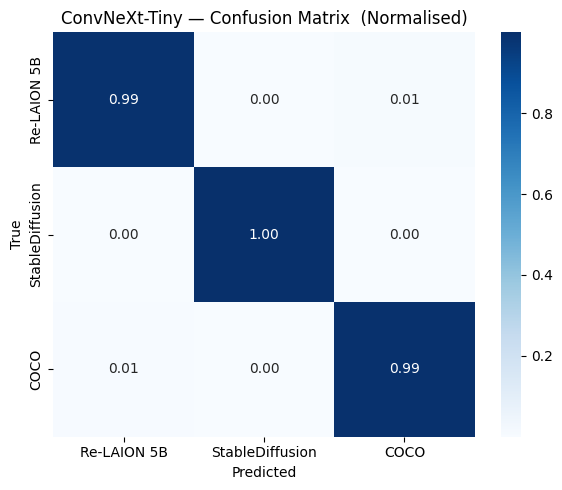

In [8]:
plot_confusion_matrix(
    cnx_y_true, cnx_y_pred, CNX_CLASS_NAMES,
    normalize=True, title="ConvNeXt-Tiny — Confusion Matrix"
)


## 1.6  Per-Class Accuracy

In [9]:
per_class_accuracy(cnx_y_true, cnx_y_pred, CNX_CLASS_NAMES)


Per-class accuracy:
  Re-LAION 5B         : 99.11%
  StableDiffusion     : 99.98%
  COCO                : 99.22%


## 1.7  One-vs-Rest ROC / AUC Curves

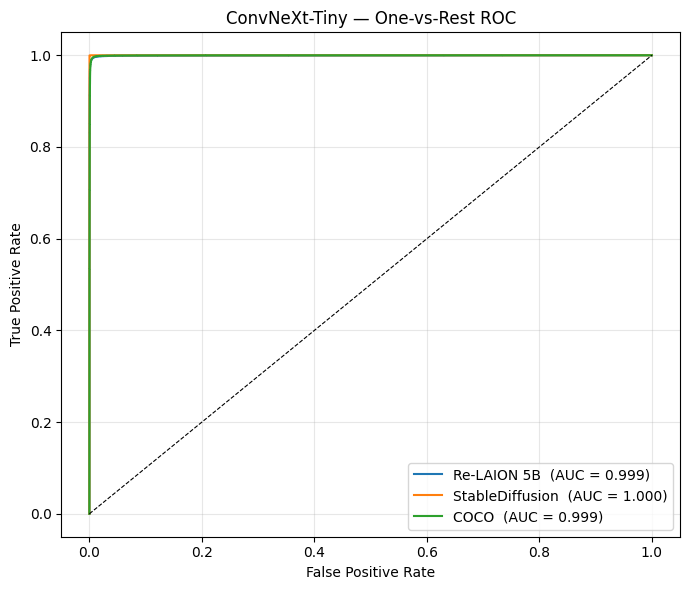

In [10]:
plot_ovr_roc(
    cnx_y_true, cnx_y_probs, CNX_CLASS_NAMES,
    title="ConvNeXt-Tiny — One-vs-Rest ROC"
)


## 1.8  Grad-CAM Visualisations

Target layer for ConvNeXt-Tiny: `model.backbone.features[-1]`

In [11]:
cnx_gradcam = GradCAM(
    model=cnx_model,
    target_layer=cnx_model.backbone.features[-1]
)

cnx_cam_entries = run_gradcam_inference(
    model=cnx_model,
    dataset=cnx_test_dataset,
    gradcam=cnx_gradcam,
    max_cams=24,
    batch_size=16,
)
print(f"Collected {len(cnx_cam_entries)} Grad-CAM entries")


Grad-CAM:   0%|          | 2/6161 [00:19<16:32:55,  9.67s/batch]

Collected 24 Grad-CAM entries


### Misclassified examples

In [12]:
cnx_misclassified = [e for e in cnx_cam_entries if e["true"] != e["pred"]]
print(f"Misclassified: {len(cnx_misclassified)} / {len(cnx_cam_entries)}")
for entry in cnx_misclassified[:6]:
    show_cam(entry, class_names=CNX_CLASS_NAMES)


Misclassified: 0 / 24


### Correctly classified examples

Correct: 24 / 24


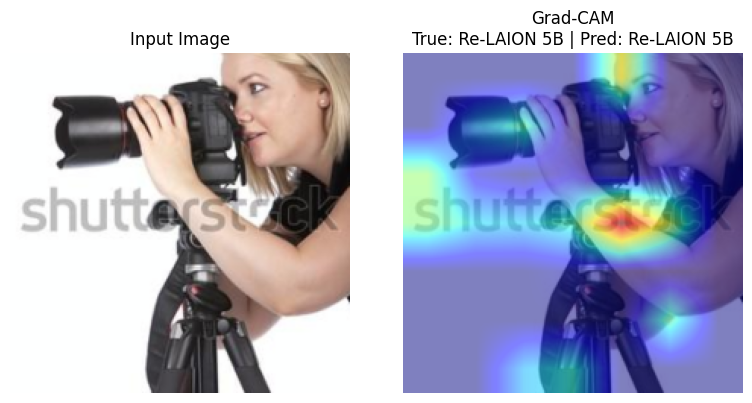

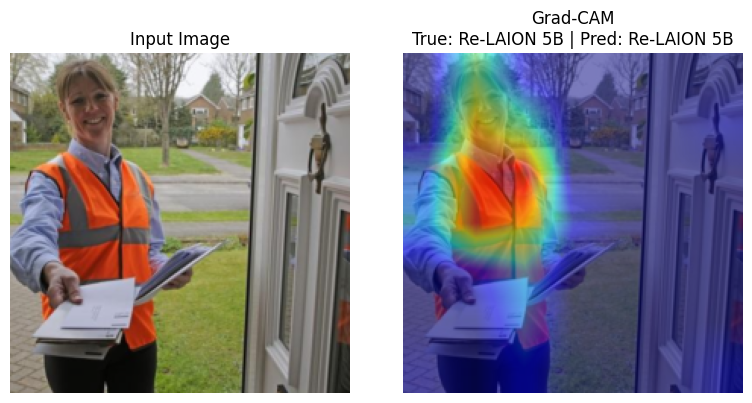

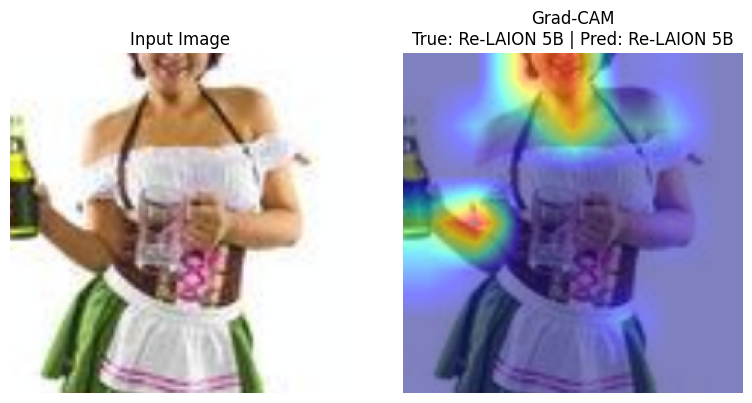

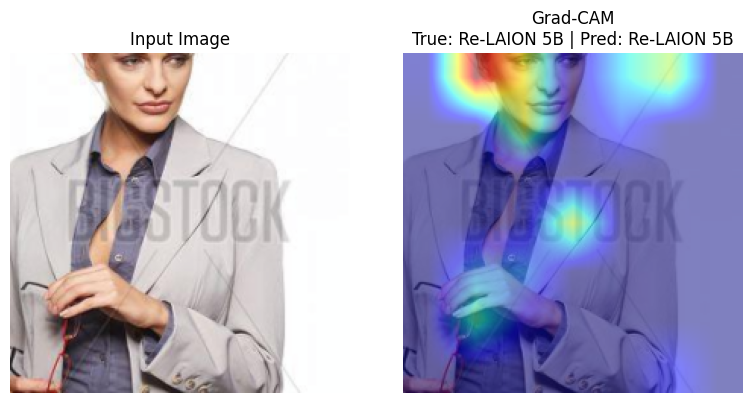

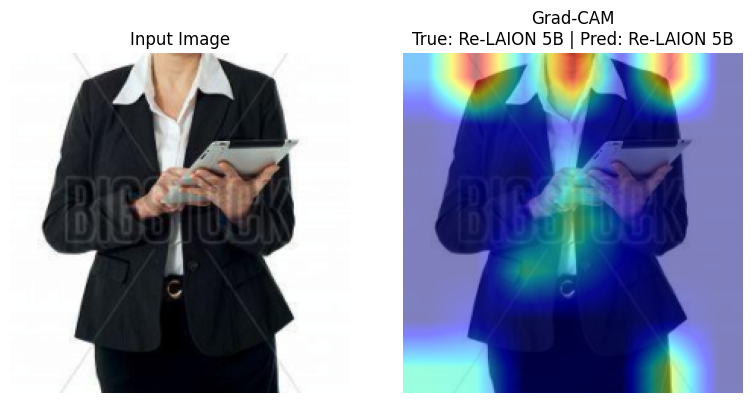

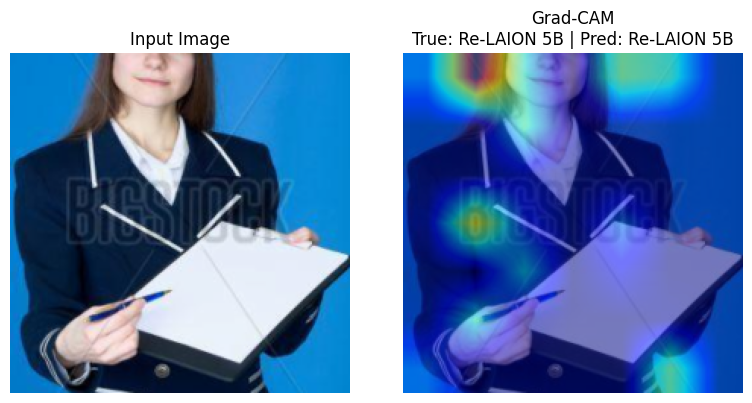

In [13]:
cnx_correct = [e for e in cnx_cam_entries if e["true"] == e["pred"]]
print(f"Correct: {len(cnx_correct)} / {len(cnx_cam_entries)}")
for entry in cnx_correct[:6]:
    show_cam(entry, class_names=CNX_CLASS_NAMES)


## 1.9  Single-Image & Directory Inference

Convenience utilities for running the model on arbitrary images.

In [ ]:
# Single image
cnx_result = predict_image(
    model=cnx_model,
    image_path=r"path\to\your\image.jpg",  # update
    transform=convnext_eval_transform(),
    class_names=CNX_CLASS_NAMES,
)
print(f"Prediction : {cnx_result['pred_label']}")
print(f"Probabilities: {dict(zip(CNX_CLASS_NAMES, cnx_result['probabilities'].round(4)))}")


In [ ]:
# Directory sweep
cnx_dir_results = run_directory_inference(
    model=cnx_model,
    image_dir=r"path\to\your\image\folder",  # update
    transform=convnext_eval_transform(),
    class_names=CNX_CLASS_NAMES,
    max_images=5_000,
)


---

# Section 2 — ResNet-50 Classifier

Attribute probe model (binary or multi-class).  
Imports from `ResNet-50_Convnext-Tiny_Classification.py`.

## 2.1  Imports

In [16]:
# The ResNet-50 script uses hyphens in its name, so we import via importlib.
import importlib.util, sys as _sys

_spec = importlib.util.spec_from_file_location(
    "resnet50_clf",
    Path(PROJECT_ROOT) / "ResNet-50_Convnext-Tiny_Classification.py"
)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)

ResNet50Probe      = _mod.ResNet50Probe
ImageLabelDataset  = _mod.ImageLabelDataset
resnet_eval_tf     = _mod.eval_transform
resnet_load_splits = _mod.load_splits
print("ResNet-50 module loaded successfully")


ResNet-50 module loaded successfully


## 2.2  Configuration

Update the paths and class settings below.

In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
RN_CHECKPOINT  = r"outputs_ResNet50\task_best_seed_0.pt"  # update this path
RN_SPLITS_JSON = r"path\to\your\splits.json"              # update this path
RN_NUM_CLASSES = 3          # 1 for binary (gender), 3 for skin-tone / 3-class
RN_CLASS_NAMES = ["Re-LAION 5B", "StableDiffusion", "COCO"]  # update as needed


## 2.3  Load Model

In [ ]:
def load_resnet50_model(checkpoint_path, num_classes, device):
    """
    ResNet-50 checkpoints are saved as plain state dicts
    (torch.save(model.state_dict(), path)), not wrapped in a dict.
    """
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = ResNet50Probe(num_classes=num_classes)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded ResNet-50 checkpoint from: {checkpoint_path}")
    return model

rn_model = load_resnet50_model(RN_CHECKPOINT, RN_NUM_CLASSES, DEVICE)


## 2.4  Load Dataset & Run Inference

In [ ]:
rn_train, rn_val, rn_test = resnet_load_splits(RN_SPLITS_JSON)

rn_test_dataset = ImageLabelDataset(rn_test, resnet_eval_tf())
print(f"Test samples: {len(rn_test_dataset):,}")


In [ ]:
rn_y_pred, rn_y_true, rn_y_probs = run_inference(
    rn_model, rn_test_dataset, batch_size=128, num_workers=4
)
print(f"Accuracy: {(rn_y_pred == rn_y_true).mean()*100:.2f}%")


## 2.5  Confusion Matrix Heatmap

In [ ]:
plot_confusion_matrix(
    rn_y_true, rn_y_pred, RN_CLASS_NAMES,
    normalize=True, title="ResNet-50 — Confusion Matrix"
)


## 2.6  Per-Class Accuracy

In [ ]:
per_class_accuracy(rn_y_true, rn_y_pred, RN_CLASS_NAMES)


## 2.7  One-vs-Rest ROC / AUC Curves

In [ ]:
plot_ovr_roc(
    rn_y_true, rn_y_probs, RN_CLASS_NAMES,
    title="ResNet-50 — One-vs-Rest ROC"
)


## 2.8  Grad-CAM Visualisations

Target layer for ResNet-50: `model.backbone.layer4` (final residual stage, output before global avg-pool).

In [ ]:
rn_gradcam = GradCAM(
    model=rn_model,
    target_layer=rn_model.backbone.layer4   # final conv stage of ResNet-50
)

rn_cam_entries = run_gradcam_inference(
    model=rn_model,
    dataset=rn_test_dataset,
    gradcam=rn_gradcam,
    max_cams=24,
    batch_size=16,
)
print(f"Collected {len(rn_cam_entries)} Grad-CAM entries")


### Misclassified examples

In [ ]:
rn_misclassified = [e for e in rn_cam_entries if e["true"] != e["pred"]]
print(f"Misclassified: {len(rn_misclassified)} / {len(rn_cam_entries)}")
for entry in rn_misclassified[:6]:
    show_cam(entry, class_names=RN_CLASS_NAMES)


### Correctly classified examples

In [ ]:
rn_correct = [e for e in rn_cam_entries if e["true"] == e["pred"]]
print(f"Correct: {len(rn_correct)} / {len(rn_cam_entries)}")
for entry in rn_correct[:6]:
    show_cam(entry, class_names=RN_CLASS_NAMES)


## 2.9  Single-Image & Directory Inference

In [ ]:
# Single image
rn_result = predict_image(
    model=rn_model,
    image_path=r"path\to\your\image.jpg",  # update
    transform=resnet_eval_tf(),
    class_names=RN_CLASS_NAMES,
)
print(f"Prediction : {rn_result['pred_label']}")
print(f"Probabilities: {dict(zip(RN_CLASS_NAMES, rn_result['probabilities'].round(4)))}")


In [ ]:
# Directory sweep
rn_dir_results = run_directory_inference(
    model=rn_model,
    image_dir=r"path\to\your\image\folder",  # update
    transform=resnet_eval_tf(),
    class_names=RN_CLASS_NAMES,
    max_images=5_000,
)
